# Clasificación de equipos

En este notebook, explicaremos el proceso para realizar la segmentación o distinción de los jugadores por equipos

## Metodología del Proceso

El flujo de trabajo se divide en cuatro etapas principales:

### 1. Detección y Extracción (Cropping)
A partir de un vídeo o un conjunto de imágenes de un mismo partido, utilizamos un modelo de detección de objetos para localizar a los jugadores. Una vez detectados, recortamos los fragmentos de imagen correspondientes para obtener "parches" o recortes que contienen únicamente al jugador.

### 2. Codificación de Características con DINO
Para que el sistema pueda comparar visualmente a los jugadores, transformamos cada recorte en una representación matemática (vector). Utilizamos **DINO (Distillation with no labels)** de Facebook, un modelo de vanguardia basado en *Vision Transformers*.
* Este modelo actúa como un **encoder**, codificando la imagen en un vector de alta dimensionalidad que captura las características visuales más relevantes, como los colores y patrones de la equipación.

### 3. Reducción de Dimensionalidad con UMAP
Los vectores generados por DINO son complejos y tienen muchas dimensiones. Para facilitar el agrupamiento, utilizamos **UMAP (Uniform Manifold Approximation and Projection)** para reducir los datos a un espacio de $\mathbb{R}^3$.

> **¿Qué es UMAP?**
> UMAP es un algoritmo de aprendizaje automático para la reducción de dimensionalidad no lineal. A diferencia de otras técnicas, destaca por su capacidad de preservar tanto la estructura local como la global de los datos. En términos sencillos, proyecta los vectores de alta dimensión en un espacio 3D intentando que los jugadores que visten igual sigan estando cerca en este nuevo mapa.

### 4. Clustering y Clasificación
Finalmente, aplicamos un algoritmo de **Clustering** sobre los vectores reducidos. Este paso agrupa automáticamente las imágenes basándose en su similitud visual:
* Los grupos resultantes representarán a los dos equipos rivales, porteros y árbitros.

**Inferencia:** De esta manera, cuando detectemos un jugador nuevo, podremos codificarlo y determinar a qué conjunto pertenece basándonos en el grupo (clúster) al que sea asignado.

---
**Detalles técnicos:**
* **Encoder:** DINOv2 (Vision Transformer).
* **Reducción:** UMAP a 3 componentes.
* **Agrupamiento:** K-Means / DBSCAN.

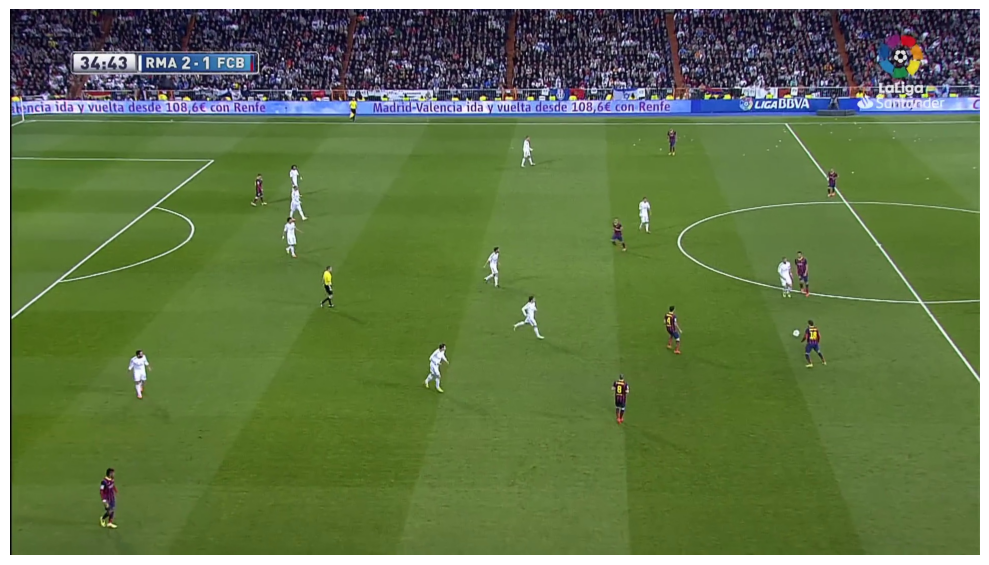

In [1]:
import os 
from ultralytics import YOLO
import supervision as sv
import numpy as np
import supervision as sv
from utils.image_tools import display_image
from utils.config import DATA_GENERATED_IMGS,BEST_OBJ_DETECTION_MODEL
import cv2


def crop_detections(image: np.ndarray, detections: sv.Detections) -> list[np.ndarray]:
    """
    Recorta los objetos detectados en una imagen y los devuelve en una lista.
    
    Args:
        image (np.ndarray): La imagen original (frame) en formato BGR.
        detections (sv.Detections): Objeto de supervision con las detecciones.
        
    Returns:
        list[np.ndarray]: Lista de imágenes recortadas (crops). 
                          Si no hay detecciones, devuelve una lista vacía [].
    """

    crops = []
    
    for bbox in detections.xyxy:
       
        x_min, y_min, x_max, y_max = map(int, bbox)
    
        crop = image[y_min:y_max, x_min:x_max]  # Recortamos usando slicing de NumPy: image[y_inicio:y_fin, x_inicio:x_fin]
        
        crops.append(crop)
            
    return crops


img_path = os.path.join(DATA_GENERATED_IMGS, os.listdir(DATA_GENERATED_IMGS)[3])
object_detection_model = YOLO(BEST_OBJ_DETECTION_MODEL)
display_image(img_path,figsize=(10,7))

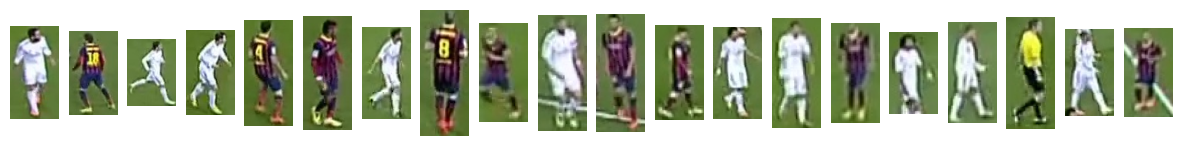

In [2]:
import matplotlib.pyplot as plt
#Ejemplo

img = cv2.imread(img_path)  # Leer la imagen usando OpenCV (en formato BGR)
detections = object_detection_model(img,verbose = False)[0]  # Obtener las detecciones del modelo
detections = sv.Detections.from_ultralytics(detections)
players = detections[detections.class_id == 1] # Convertir a formato de supervision
crops = crop_detections(img, players)

plt.figure(figsize=(15, 5)) # Tamaño general

for i, crop in enumerate(crops):
    plt.subplot(1, len(crops), i + 1) # (filas, columnas, posición)
    plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)) # Convertir color y mostrar
    plt.axis('off') # Quitar los números

plt.show()


Una vez tenemos los recortes, codificamos dichas imágenes:

In [3]:
import torch
import cv2
import numpy as np
import torchvision.transforms as transforms
from PIL import Image
from umap import UMAP  # Corrección: importación específica
from sklearn.cluster import KMeans  # Corrección: importación faltante

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# DINOv2
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device)
model.eval()

# Transformaciones estándar para DINOv2
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def encode(crops):
    """
    Convierte una lista de recortes (OpenCV BGR) en embeddings numéricos.
    """
    
    batch_tensors = []
    for crop in crops:

        # 1. Conversión de BGR a RGB y a PIL
        img_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(img_rgb)
        
        img_tensor = transform(img_pil)
        batch_tensors.append(img_tensor)
    
    # 3. Procesamiento en lote (Batch) para mayor velocidad
    input_batch = torch.stack(batch_tensors).to(device)
    
    with torch.no_grad():
        embeddings = model(input_batch)
    
    return embeddings.cpu().numpy()



features = encode(crops)

reducer = UMAP(n_components=3, n_neighbors=min(15, len(crops)-1), random_state=42)
features_3d = reducer.fit_transform(features)


kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(features_3d)
    


Using cache found in /home/adrian/.cache/torch/hub/facebookresearch_dinov2_main


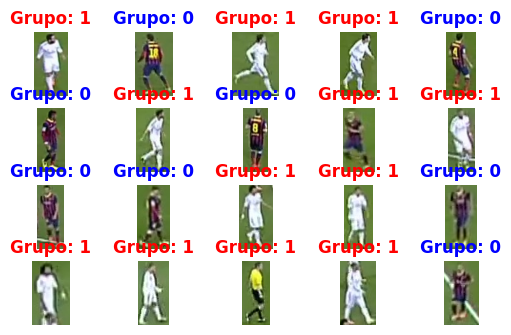

<Figure size 2000x2000 with 0 Axes>

In [4]:
cols = 5
rows = (len(crops) // cols) + 1

for i, (crop, label) in enumerate(zip(crops, labels)):
    plt.subplot(rows, cols, i + 1)

    img_show = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    plt.imshow(img_show)
    
    color = 'blue' if label == 0 else 'red'
    plt.title(f"Grupo: {label}", color=color, fontweight='bold')
    plt.axis('off')

plt.figure(figsize=(20, 20))
plt.tight_layout()
plt.show()

# Video 

La metodología explicada hasta ahora es intuitiva y funciona perfectamente cuando trabajamos con una sola imagen o un conjunto reducido de fotografías: detectamos, recortamos todos los jugadores y aplicamos clustering. Sin embargo, en un entorno de **vídeo**, extraer y almacenar los recortes de todos los jugadores en cada frame (hablamos de miles de imágenes por minuto) es computacionalmente ineficiente e inestable.

Para resolver este problema, modificaremos el flujo de trabajo dividiéndolo en dos fases: una de **calibración** y otra de **inferencia**.

### Fase 1: Muestreo y Calibración (Preprocesado)
En lugar de procesar todo el vídeo de golpe, realizaremos una pasada rápida inicial para recolectar una muestra representativa. 
* Analizaremos diferentes momentos del partido (por ejemplo, saltando frames) hasta extraer alrededor de **500 recortes** de jugadores.
* Pasaremos esta muestra por nuestro encoder (DINOv2) y utilizaremos estos vectores para **ajustar** nuestros modelos de UMAP y KMeans. 
* Con este paso, el algoritmo "aprende" la paleta de colores y las características visuales de las dos equipaciones de *este partido en concreto*.

### Fase 2: Inferencia Continua Frame a Frame
Una vez que conocemos la definición visual de los dos conjuntos (clústeres), volvemos a procesar el vídeo de principio a fin.
* En cada frame, el modelo de detección localizará a los jugadores y generará sus recortes.
* Pasaremos estos nuevos recortes por el encoder, pero **no recalcularemos los clústeres**.
* Simplemente proyectaremos los vectores en el espacio UMAP ya calibrado y el algoritmo KMeans determinará instantáneamente a qué conjunto pertenece cada jugador basándose en su cercanía a los grupos previamente definidos.

Para ello implementamos una clase llamada TeamSegmentation en `src/team_segmentation/team_segmentatio.py` donde implementaremos estas funciones.

Por otro lado, combinaremos todo este flujo con el modelo de detección de puntos claves para calcular las homografías y las posiciones de los jugadores en el campo real. Aprovecharemos la distincion de equipos para también distinguir dichos puntos en el mapa 2D.

In [ ]:
from team_segmentation.team_segmentation import TeamSegmentation
from utils.config import VIDEOS_DIR, BEST_OBJ_DETECTION_MODEL,BEST_KPT_MODEL
from utils.image_tools import annotate_ball,draw_annotations,draw_keypoints
from pitch_keypoints.homography import get_homography
from utils.pitch import draw_pitch,draw_objects_on_pitch,overlay_pitch_on_image
from utils.video_tools import process_and_write_video
import os
%reload_ext autoreload
%autoreload 2


video = os.path.join(VIDEOS_DIR, "downloaded","video_1.mp4")

object_detection_model = YOLO(BEST_OBJ_DETECTION_MODEL)
kpt_model = YOLO(BEST_KPT_MODEL)

team_segmenter = TeamSegmentation()
team_segmenter.preprocess_from_video(video,object_detection_model)

H = None  # Homografia 
pitch  = draw_pitch()
number_frame = 0
def write_frame(frame, **kwargs):
    global H

    
    #Detectamos entidades
    detections = object_detection_model(frame,verbose = False)[0]
    detections = sv.Detections.from_ultralytics(detections)

    referees = detections[detections.class_id == 2]
    players = detections[detections.class_id == 1]
    ball = detections[detections.class_id == 0]

    annotated_frame = annotate_ball(frame, ball)
    annotated_frame = draw_annotations(annotated_frame, referees,color="#00FF00",stylized=True)


    #Segmentamos jugadores por equipo
    team_a, team_b = team_segmenter.predict_teams(frame, players)

    annotated_frame = draw_annotations(annotated_frame, team_a, color="#1900FF",stylized=True)
    annotated_frame = draw_annotations(annotated_frame, team_b, color="#FF0000",stylized=True)

    #Calculamos homografia
    
    kpts = kpt_model(frame,verbose = False)[0]
    annotated_frame = draw_keypoints(kpts,annotated_frame,conf_threshold=0.6)
    new_pitch = pitch

    #Calculamos Homografia: Pixeles a Mapa2D
    if number_frame % 25 == 0 or H is None: # No es necesario calcular homografia en cada frame, lo hacemos cada 25 frames
        new_H = get_homography(kpts.keypoints.data,conf = 0.6)

        if new_H is not None:
            H = new_H

    #Equipo A
   
    tg_positions = team_segmenter.calculate_target_positions(H,team_a)
    new_pitch = draw_objects_on_pitch(pitch, tg_positions, color="#1900FF", object_size=10)

    #Equipo B
    tg_positions = team_segmenter.calculate_target_positions(H,team_b)
    new_pitch = draw_objects_on_pitch(new_pitch, tg_positions, color="#FF0000", object_size=10)

    annotated_frame = overlay_pitch_on_image(annotated_frame, new_pitch)

    number_frame += 1

    return annotated_frame


output = os.path.join(VIDEOS_DIR,"team_segmentation","video_1_processed.mp4")
process_and_write_video(video, output_path=output,process_frame_func=write_frame)


Using cache found in /home/adrian/.cache/torch/hub/facebookresearch_dinov2_main
Procesando video:  15%|█▌        | 208/1349 [01:00<05:29,  3.46it/s]


UnboundLocalError: cannot access local variable 'H' where it is not associated with a value